========== LOADING DATASET ==========

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset shape: (150, 5)

After dropping species column:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6  

C:\Users\Diana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


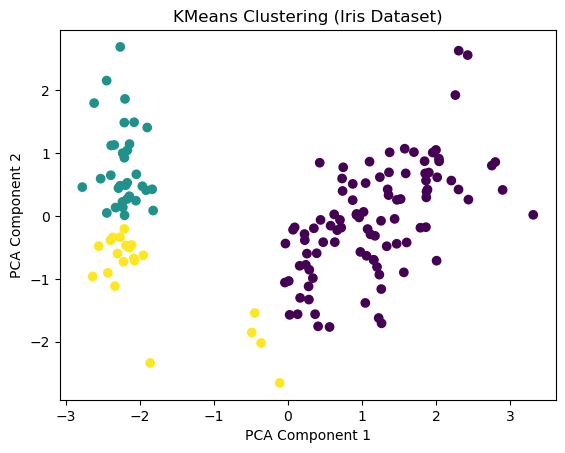



========== HIERARCHICAL CLUSTERING ==========

Description of Hierarchical Clustering:
Hierarchical clustering builds a tree-like structure (dendrogram).
There are two types:
1. Agglomerative (Bottom-Up)
2. Divisive (Top-Down)
In this assignment, we use Agglomerative clustering.

Why Hierarchical Clustering is suitable for Iris dataset?
- It does not require random initialization.
- It can show hierarchy of clusters.
- Suitable for small datasets like Iris.

Cluster labels for first 10 samples:
[1 1 1 1 1 1 1 1 1 1]


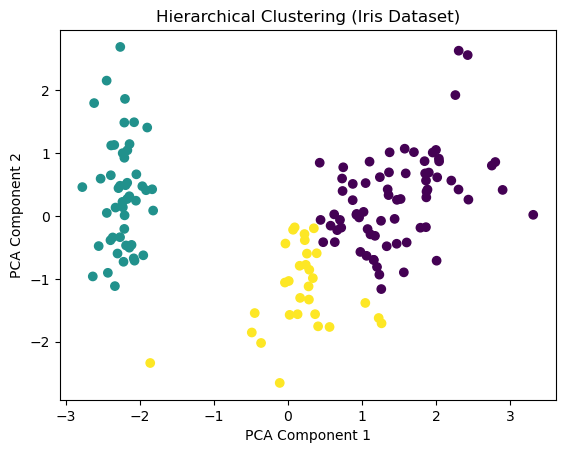

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#  LOADING AND PREPROCESSING 
print("========== LOADING DATASET ==========\n")

# Load Iris dataset from sklearn
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add species column temporarily
df['species'] = iris.target

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset shape:", df.shape)

# Drop species column (since this is clustering)
X = df.drop(columns=['species'])

print("\nAfter dropping species column:")
print(X.head())
print("Shape of dataset:", X.shape)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData has been standardized.")
print("Sample standardized data (first 5 rows):")
print(X_scaled[:5])

# KMEANS CLUSTERING 

print("\n\n========== KMEANS CLUSTERING ==========\n")

# Brief Description
print("Description of KMeans:")
print("KMeans is a partition-based clustering algorithm.")
print("It divides data into K clusters by minimizing within-cluster variance.")
print("It works by:")
print("1. Selecting K centroids randomly.")
print("2. Assigning points to nearest centroid.")
print("3. Updating centroids.")
print("4. Repeating until convergence.\n")

print("Why KMeans is suitable for Iris dataset?")
print("- Iris dataset has 3 natural groups.")
print("- It is numerical and well-structured.")
print("- KMeans works well with compact clusters.\n")

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Cluster Centers (Standardized Values):")
print(kmeans.cluster_centers_)

print("\nCluster labels for first 10 samples:")
print(kmeans_labels[:10])

# Visualization using PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("KMeans Clustering (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# HIERARCHICAL CLUSTERING 
print("\n\n========== HIERARCHICAL CLUSTERING ==========\n")

# Brief Description
print("Description of Hierarchical Clustering:")
print("Hierarchical clustering builds a tree-like structure (dendrogram).")
print("There are two types:")
print("1. Agglomerative (Bottom-Up)")
print("2. Divisive (Top-Down)")
print("In this assignment, we use Agglomerative clustering.\n")

print("Why Hierarchical Clustering is suitable for Iris dataset?")
print("- It does not require random initialization.")
print("- It can show hierarchy of clusters.")
print("- Suitable for small datasets like Iris.\n")

# Apply Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

print("Cluster labels for first 10 samples:")
print(hc_labels[:10])

# Visualization
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
